# Trust Without Verification — End-to-End Analysis Notebook

**Companion to:** *Trust Without Verification: One in Seven AI-Judged High-Stakes Tasks Proceeds with Minimal Human Oversight* (Nageshwaran & Ezekiel, 2026).

This notebook reproduces **every number, table, and figure** in the paper, top to bottom, from the public Anthropic *enabling-independent-research* dataset (CC-BY-4.0). It is self-contained: it downloads the data, defines the helper functions, runs each of the five analyses with narrated explanation, and renders the four paper figures inline.

**How to read it.** Each section opens with a plain-language explanation of *what* we are measuring and *why*, then shows the code and its output. Statistical choices (censoring policy, weighting, bootstraps, NaN handling) are explained where they first appear.

**The one rule that governs everything:** every label in this dataset — "high-stakes", "minimal human input", "fully autonomous", "clear success" — was assigned by Anthropic's Claude-based *Insights* pipeline, not by a human. So every finding is **AI-judged**, and we phrase it that way throughout.

---
## 0. Setup — dependencies, data download, and the data model

### 0.1 What the dataset actually contains

The release does **not** contain conversations. It contains **clusters**: groups of conversations that answered one researcher-defined question (a *facet*) the same way. Four CSV files:

| File | Rows × Cols | Source | Product |
|---|---|---|---|
| `stanford_clusters.csv` | 974 × 600 | Stanford SALT | Claude.ai |
| `metr_clusters.csv` | 604 × 163 | METR | Claude Code |
| `oxford_clusters.csv` | 472 × 310 | Oxford HIP | Claude.ai (emotion/UX) |
| `metr_addendum_clusters.csv` | 27 × 131 | METR follow-up | Claude Code |

Each study sampled ~250,000 conversations from a fixed **April–May 2026** window, **Free/Pro/Max consumer users only**. We use the Stanford and METR files; Oxford has no stakes/oversight facet and no shared cross-tab, so it is excluded.

**Column grammar.** For a cluster row: `num_records` = number of conversations; `ratio` (+95% CI) = the cluster's share of the run. Cross-facet columns `X:v_num_records` and `X:v_ratio` give, *within that cluster*, the count and share of conversations with value `v` on facet `X`.

**The critical subtlety — censoring.** An empty cross-facet cell means the intersection was either not computed **or fell below a privacy threshold**. We never silently treat it as zero. The smallest non-zero cross-facet count anywhere in the Stanford file is **15**, which we use as the threshold proxy: a censored cell holds between 0 and 14 conversations. Every cluster-level aggregate is reported under two policies (censored→0, and censored-dropped) plus, where it matters, a censoring-aware upper bound.

In [1]:
import subprocess, sys
for pkg in ["pandas", "numpy", "matplotlib"]:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

import os, json
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 3.0.2 | numpy 2.4.4


In [2]:
# Download the four CSVs (idempotent: skips files already present).
import urllib.request
BASE = "https://huggingface.co/datasets/Anthropic/enabling-independent-research/resolve/main/"
FILES = {
    "stanford": "stanford_clusters.csv",
    "metr": "metr_clusters.csv",
    "oxford": "oxford_clusters.csv",
    "metr_addendum": "metr_addendum_clusters.csv",
}
os.makedirs("data", exist_ok=True)
for name, fn in FILES.items():
    path = os.path.join("data", fn)
    if not os.path.exists(path):
        print("downloading", fn, "...")
        urllib.request.urlretrieve(BASE + fn, path)
    print(f"{fn:32s} {os.path.getsize(path):>10,} bytes")

def load(name):
    return pd.read_csv(os.path.join("data", FILES[name]), low_memory=False)

for n in FILES:
    print(n, load(n).shape)

stanford_clusters.csv             2,436,778 bytes
metr_clusters.csv                 1,460,388 bytes
oxford_clusters.csv               1,676,670 bytes
metr_addendum_clusters.csv           40,563 bytes


stanford (974, 600)


metr (604, 163)
oxford (472, 310)
metr_addendum (27, 131)


### 0.2 Helper functions

These are the statistical primitives used throughout:

- **`facet(df, facet_id, level=0)`** — pull the rows of one facet at one hierarchy level (level 0 = granular).
- **`xcol(...)`** — build a cross-facet column name.
- **`weighted_share(...)`** — a `num_records`-weighted proportion across a set of clusters, with an explicit `nan_policy` (`"zero"` counts censored cells as 0; `"drop"` removes clusters with any censored cell). This is the honest core of the whole analysis.
- **`wilson(...)`** — Wilson score 95% interval for a single proportion (used for conversation-level facet tables, which have **no** censored cells).
- **`bootstrap_weighted_share(...)`** — cluster bootstrap: resample clusters with replacement 5,000× and recompute the weighted share, giving a CI that reflects between-cluster variability.
- **`weighted_corr(...)`** — `num_records`-weighted Pearson correlation.

In [3]:
def facet(df, facet_id, level=0):
    return df[(df.facet_id == facet_id) & (df.level == level)].copy()

def xcol(facet_id, value, kind="ratio"):
    return f"{facet_id}:{value}_{kind}"

def weighted_share(rows, facet_id, values, nan_policy="zero"):
    """num_records-weighted share of `values` on cross-facet `facet_id`."""
    cols = [xcol(facet_id, v, "num_records") for v in values]
    sub = rows[["num_records"] + cols].copy()
    if nan_policy == "drop":
        sub = sub.dropna(subset=cols)
    else:
        sub[cols] = sub[cols].fillna(0)
    num = sub[cols].sum().sum()
    den = sub["num_records"].sum()
    return (num / den if den else np.nan), num, den, len(sub)

def wilson(p, n, z=1.96):
    if n == 0 or np.isnan(p):
        return (np.nan, np.nan)
    d = 1 + z**2 / n
    c = (p + z**2 / (2 * n)) / d
    h = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / d
    return (c - h, c + h)

def bootstrap_weighted_share(rows, facet_id, values, n_boot=5000, seed=0, nan_policy="zero"):
    rng = np.random.default_rng(seed)
    cols = [xcol(facet_id, v, "num_records") for v in values]
    sub = rows[["num_records"] + cols].copy()
    if nan_policy == "drop":
        sub = sub.dropna(subset=cols)
    else:
        sub[cols] = sub[cols].fillna(0)
    num = sub[cols].sum(axis=1).to_numpy()
    den = sub["num_records"].to_numpy()
    k = len(sub)
    if k == 0:
        return (np.nan, np.nan, np.nan)
    point = num.sum() / den.sum()
    idx = rng.integers(0, k, size=(n_boot, k))
    boots = num[idx].sum(axis=1) / den[idx].sum(axis=1)
    return point, float(np.percentile(boots, 2.5)), float(np.percentile(boots, 97.5))

def weighted_corr(x, y, w):
    x, y, w = map(np.asarray, (x, y, w))
    m = ~(np.isnan(x) | np.isnan(y))
    x, y, w = x[m], y[m], w[m]
    mx, my = np.average(x, weights=w), np.average(y, weights=w)
    cov = np.average((x - mx) * (y - my), weights=w)
    vx = np.average((x - mx) ** 2, weights=w)
    vy = np.average((y - my) ** 2, weights=w)
    return cov / np.sqrt(vx * vy), int(m.sum())

print("helpers defined")

helpers defined


In [4]:
# Figure styling (matches the paper's validated palette).
C = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
INK, INK2, MUTED, GRID, AXIS = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
plt.rcParams.update({
    "font.family": "sans-serif", "font.size": 9, "axes.edgecolor": AXIS, "axes.labelcolor": INK2,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "figure.facecolor": "white", "axes.facecolor": "white", "legend.frameon": False, "figure.dpi": 110,
})
def as_pct(ax, axis="y"):
    f = matplotlib.ticker.FuncFormatter(lambda v, _: f"{v*100:.0f}%")
    (ax.yaxis if axis == "y" else ax.xaxis).set_major_formatter(f)

---
## 1. Reproducing the published verified findings

Before any new analysis, we reproduce the numbers Anthropic and the Stanford/METR teams reported, to confirm our reading of the file grammar is correct. If these don't match, nothing downstream can be trusted. We check the **task-criticality distribution**, the **low-oversight rate by criticality** (the headline), engagement, the named high-stakes clusters, and the METR supervision/outcome numbers.

In [5]:
st = load("stanford")
LOW = ["minimal_human_input", "ai_handles_alone"]   # our definition of "low oversight"

# Task-criticality distribution (share of ALL conversations)
crit = facet(st, "task_criticality").set_index("cluster_name")
dist = crit[["num_records", "ratio"]].rename(columns={"ratio": "share"})
dist["share_%"] = (dist.share * 100).round(1)
dist.sort_values("num_records", ascending=False)

,num_records,share,share_%
cluster_name,,,
not_applicable,85848,0.343620,34.4
consequential,72745,0.291173,29.1
operational,39148,0.156696,15.7
ephemeral,32646,0.130671,13.1
high_stakes,19447,0.077840,7.8


**Reading it.** 34.4% of conversations are `not_applicable` (no meaningful stakes judgement), and only **7.8%** are AI-judged high-stakes (n = 19,447). These match the reported distribution exactly.

Now the headline: within each criticality level, what share of conversations had **low oversight** (`minimal_human_input` + `ai_handles_alone`)? Because `task_criticality` is a categorical facet, its level-0 rows *are* the facet values, so this cross-tab is **conversation-level with no censored cells** — the strongest kind of number in the dataset.

In [6]:
rows = []
for c in ["high_stakes", "consequential", "operational", "ephemeral", "not_applicable"]:
    n = int(crit.loc[c, "num_records"])
    low_n = sum(crit.loc[c, xcol("human_agency_level", a, "num_records")] for a in LOW)
    p = low_n / n
    lo, hi = wilson(p, n)
    rows.append({
        "criticality": c, "n": n,
        "low_oversight_%": round(p * 100, 1),
        "CI_low": round(lo * 100, 1), "CI_high": round(hi * 100, 1),
        "direct_use_%": round(crit.loc[c, xcol("engagement_with_output", "direct_use")] * 100, 1),
        "one_in_x": round(1 / p, 1),
    })
gradient = pd.DataFrame(rows)
gradient

,criticality,n,low_oversight_%,CI_low,CI_high,direct_use_%,one_in_x
0,high_stakes,19447,14.7,14.3,15.2,10.2,6.8
1,consequential,72745,21.3,21.0,21.6,11.4,4.7
2,operational,39148,28.6,28.2,29.1,13.5,3.5
3,ephemeral,32646,24.3,23.8,24.8,14.9,4.1
4,not_applicable,85848,8.2,8.0,8.4,6.2,12.2


**The core result of the paper.** Low oversight falls monotonically as stakes rise — 28.6% (operational) → 21.3% (consequential) → **14.7% (high-stakes)**, i.e. **one in 6.8**, which "one in seven" fairly describes. The gradient is real but *shallow*: even for the highest-stakes work the labelling model judges, roughly one in seven conversations proceeds with minimal human involvement. Note this is an **exact count over 19,447 conversations with no censoring**, which is why we can anchor the title on it.

In [7]:
# Named high-stakes task clusters (descriptive facet, 61 clusters, sum to 19,447).
hs = facet(st, "high_stakes_task_description")
print("n high-stakes clusters:", len(hs), "| sum num_records:", int(hs.num_records.sum()))
cnt = [xcol("human_agency_level", a, "num_records") for a in LOW]
hs["low_reported"] = hs[cnt].fillna(0).sum(axis=1) / hs.num_records
hs["n_censored"] = hs[cnt].isna().sum(axis=1)
named = ["Submit a regulatory compliance filing","Execute a high-stakes financial decision",
         "Deploy a production application","Publish content across public platforms",
         "Resolve a critical production system failure","Complete a high-stakes tax compliance filing"]
show = hs.set_index(hs.cluster_name.str.strip()).loc[named, ["num_records","low_reported","n_censored"]]
show["low_reported_%"] = (show.low_reported*100).round(1)
show[["num_records","low_reported_%","n_censored"]]

n high-stakes clusters: 61 | sum num_records: 19447


,num_records,low_reported_%,n_censored
cluster_name,,,
Submit a regulatory compliance filing,2038,20.7,0
Execute a high-stakes financial decision,918,18.0,1
Deploy a production application,823,18.3,1
Publish content across public platforms,559,29.5,0
Resolve a critical production system failure,974,7.9,1
Complete a high-stakes tax compliance filing,765,8.0,1


Note `n_censored`: in most high-stakes clusters the `ai_handles_alone` cell is censored (below 15), so the *reported* low-oversight share here is a **lower bound**. That is exactly why Section 3 builds a censoring-aware upper bound. The technical clusters (production failure 7.9%, tax filing 8.0%) already look lower than the regulatory/financial ones (18–21%) — the "engineer asymmetry" we test formally next.

In [8]:
# METR side: supervision distribution and outcome by supervision level (conversation-level, uncensored).
me = load("metr")
sup = facet(me, "supervision_intensity").set_index("cluster_name")
SUP = ["fully_autonomous", "lightly_supervised", "collaborative", "actively_supervised"]
SUC = ["clear_success", "partial_success", "clear_failure", "abandoned_or_unclear"]
tab = pd.DataFrame({
    "n": [int(sup.loc[s, "num_records"]) for s in SUP],
    "share_%": [round(sup.loc[s, "ratio"]*100, 1) for s in SUP],
    **{s + "_%": [round(sup.loc[k, xcol("task_success", s)]*100, 1) for k in SUP] for s in SUC},
}, index=SUP)
tab

,n,share_%,clear_success_%,partial_success_%,clear_failure_%,abandoned_or_unclear_%
fully_autonomous,105878,42.8,71.4,3.7,2.4,22.5
lightly_supervised,39606,16.0,68.8,22.3,0.4,8.5
collaborative,52951,21.4,46.1,30.0,1.8,22.1
actively_supervised,48634,19.7,48.6,42.9,2.6,5.9


**METR reproduction.** 42.8% of Claude Code sessions are AI-judged fully autonomous. Autonomous and lightly-supervised sessions show high clear-success (71.4%, 68.8%); collaborative/actively-supervised are much lower (46.1%, 48.6%) but pick up "partial success" instead. Autonomous sessions also carry a **22.5% abandoned-or-unclear** tail — the "unwatched ending" quantified in Section 5. All of these match the reported figures.

---
## 2. Robustness of the oversight–stakes gradient (+ Figure 1)

The headline is an exact count, but a careful reader wants three checks: (a) Wilson CIs and pairwise differences; (b) an **independent re-aggregation** over the 61 high-stakes clusters (which partition the same 19,447 conversations) under both NaN policies plus a censoring-aware upper bound; (c) an ecological check across the 185 `request` clusters.

In [9]:
# (a) pairwise differences vs high-stakes (independent proportions)
r = gradient.set_index("criticality")
for c in ["consequential", "operational"]:
    p1, n1 = r.loc["high_stakes","low_oversight_%"]/100, r.loc["high_stakes","n"]
    p2, n2 = r.loc[c,"low_oversight_%"]/100, r.loc[c,"n"]
    se = np.sqrt(p1*(1-p1)/n1 + p2*(1-p2)/n2)
    d = p2 - p1
    print(f"{c:14s} - high_stakes = +{d*100:4.1f} pp   95% CI [{(d-1.96*se)*100:.1f}, {(d+1.96*se)*100:.1f}]")

consequential  - high_stakes = + 6.6 pp   95% CI [6.0, 7.2]
operational    - high_stakes = +13.9 pp   95% CI [13.2, 14.6]


In [10]:
# (b) cluster re-aggregation under both NaN policies + censoring-aware upper bound
THRESH = 15   # privacy threshold proxy (smallest non-zero cross-facet count)
p0, lo0, hi0 = bootstrap_weighted_share(hs, "human_agency_level", LOW, nan_policy="zero")
pdrop = weighted_share(hs, "human_agency_level", LOW, nan_policy="drop")[0]

# upper bound: each censored low-oversight cell holds at most THRESH-1, capped by unallocated row mass
rep_cols = [xcol("human_agency_level", a) for a in
            ["ai_handles_alone","complete_human_involvement","equal_partnership",
             "human_leads_ai_assists","minimal_human_input","not_applicable"]]
hs["missing_mass"] = ((1 - hs[rep_cols].sum(axis=1)) * hs.num_records).round().clip(lower=0)
hs["low_n_lower"] = hs[cnt].fillna(0).sum(axis=1)
hs["low_n_upper"] = hs.low_n_lower + np.minimum(hs.n_censored*(THRESH-1), hs.missing_mass)
rng = np.random.default_rng(1); num = hs.low_n_upper.to_numpy(); den = hs.num_records.to_numpy()
idx = rng.integers(0, len(hs), size=(5000, len(hs)))
b = num[idx].sum(1)/den[idx].sum(1)
print(f"facet-level exact          : 14.7%  (Wilson 14.3-15.2)")
print(f"cluster re-agg  NaN->0     : {p0*100:4.1f}%  (bootstrap {lo0*100:.1f}-{hi0*100:.1f})")
print(f"cluster re-agg  NaN dropped: {pdrop*100:4.1f}%  (only 2 clusters survive - uninformative)")
print(f"censoring-aware upper bound: {num.sum()/den.sum()*100:4.1f}%  (bootstrap {np.percentile(b,2.5)*100:.1f}-{np.percentile(b,97.5)*100:.1f})")

facet-level exact          : 14.7%  (Wilson 14.3-15.2)
cluster re-agg  NaN->0     : 13.1%  (bootstrap 10.1-15.5)
cluster re-agg  NaN dropped: 22.6%  (only 2 clusters survive - uninformative)
censoring-aware upper bound: 16.9%  (bootstrap 14.6-19.1)


**What this shows.** The exact 14.7% sits inside the bracket [13.1% lower bound, 16.9% worst-case upper bound]. The 1.7-point gap between the lower bound and the exact figure is *precisely* the mass hidden by censoring (`ai_handles_alone` is censored in 59 of 61 clusters). The number is robust; "one in seven" honestly describes it.

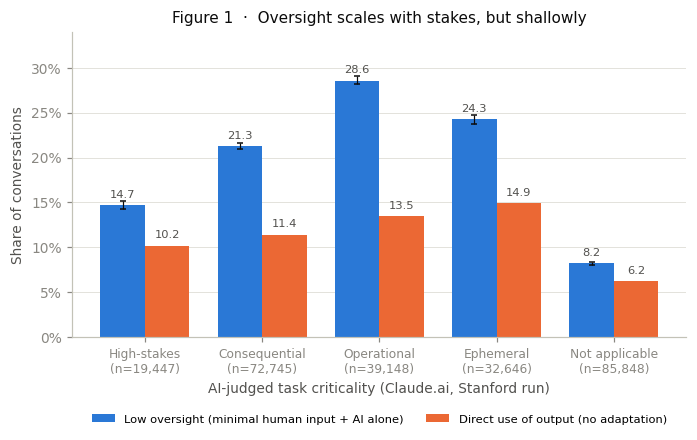

In [11]:
# ---- Figure 1: low-oversight and direct-use by criticality
order = ["high_stakes","consequential","operational","ephemeral","not_applicable"]
lab = {"high_stakes":"High-stakes","consequential":"Consequential","operational":"Operational",
       "ephemeral":"Ephemeral","not_applicable":"Not applicable"}
gg = gradient.set_index("criticality").loc[order]
x = np.arange(len(order)); w = 0.38
fig, ax = plt.subplots(figsize=(7.2, 3.6))
b1 = ax.bar(x-w/2, gg.low_oversight_/100 if False else gg["low_oversight_%"]/100, w, color=C[0],
            label="Low oversight (minimal human input + AI alone)")
b2 = ax.bar(x+w/2, gg["direct_use_%"]/100, w, color=C[1], label="Direct use of output (no adaptation)")
ax.errorbar(x-w/2, gg["low_oversight_%"]/100,
            yerr=[(gg["low_oversight_%"]-gg["CI_low"])/100, (gg["CI_high"]-gg["low_oversight_%"])/100],
            fmt="none", ecolor=INK, elinewidth=0.8, capsize=2)
for bars in (b1,b2):
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.006, f"{bar.get_height()*100:.1f}",
                ha="center", va="bottom", fontsize=7.5, color=INK2)
ax.set_xticks(x); ax.set_xticklabels([f"{lab[c]}\n(n={int(gg.loc[c,'n']):,})" for c in order], fontsize=8)
ax.set_ylabel("Share of conversations"); as_pct(ax); ax.set_ylim(0, 0.34)
ax.set_xlabel("AI-judged task criticality (Claude.ai, Stanford run)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5,-0.22), ncol=2, fontsize=7.5)
ax.grid(axis="x", visible=False); ax.set_title("Figure 1  ·  Oversight scales with stakes, but shallowly", fontsize=10, color=INK)
plt.show()

---
## 3. The engineer asymmetry (+ Figure 4)

Within high-stakes work, are *technical* tasks (production outages, deployments) supervised more or less closely than *legal/financial/compliance* tasks? We group the 61 clusters by a **hand-assigned domain** table (transparent and editable — this is a judgement call the paper flags), then compare `num_records`-weighted low-oversight shares with cluster bootstraps, under the reported lower bound and the censoring-aware upper bound.

In [12]:
DOMAIN = {
    # ---- technical: software / infrastructure / security engineering
    "Resolve a critical production system failure": "technical",
    "Deploy a production application": "technical",
    "Execute a safety-critical engineering task": "technical",
    "Audit and remediate production security vulnerabilities": "technical",
    "Secure or Recover Authentication Systems": "technical",
    "Execute a production system migration": "technical",
    "Modify or delete production system data": "technical",
    "Configure and secure production network infrastructure": "technical",
    "Override Critical Safety Controls": "technical",
    "Deploy a high-stakes regulated system": "technical",
    "Deploy a high-stakes AI system": "technical",
    "Deploy production email infrastructure": "technical",
    "Modify Low-Level System Infrastructure": "technical",
    "Configure a critical business system": "technical",
    "Deploy a production AI agent": "technical",
    "Deploy production systems with credential management": "technical",
    "Deploy automated systems with infrastructure access": "technical",
    "Administer enterprise IT infrastructure": "technical",
    "Deploy a large-scale automated outreach system": "technical",
    # ---- legal / regulatory / compliance
    "Submit a regulatory compliance filing": "legal_compliance",
    "Draft and File Formal Legal Documents": "legal_compliance",
    "Draft and Finalize Binding Legal Documents": "legal_compliance",
    "Complete a high-stakes tax compliance filing": "legal_compliance",
    "Finalize a High-Stakes Formal Submission": "legal_compliance",
    "Submit a formal academic or legal document": "legal_compliance",
    "Manage formal legal document workflows": "legal_compliance",
    "Submit a formal immigration filing": "legal_compliance",
    "Resolve a High-Stakes Financial Legal Dispute": "legal_compliance",
    "Resolve a high-stakes employment legal matter": "legal_compliance",
    "Draft High-Stakes Family Legal Documents": "legal_compliance",
    "Negotiate a high-stakes legal agreement": "legal_compliance",
    "Submit high-stakes formal documents": "legal_compliance",
    "Administer a high-stakes estate legally": "legal_compliance",
    "Resolve a high-stakes legal or compliance matter": "legal_compliance",
    "Navigate high-stakes regulatory compliance tasks": "legal_compliance",
    "File a high-stakes regulatory or legal claim": "legal_compliance",
    # ---- financial
    "Execute a high-stakes financial decision": "financial",
    "Execute a High-Stakes Real Estate Transaction": "financial",
    "Deploy a live automated trading system": "financial",
    "Formalize a Complex Business Transaction": "financial",
    "Launch a High-Stakes Business Venture": "financial",
    "Structure a complex financial investment vehicle": "financial",
    "Execute a high-stakes financial transaction": "financial",
    "Assess high-stakes fraud risk": "financial",
    # ---- medical / health
    "Make high-stakes clinical medical decisions": "medical",
    "Triage an acute medical emergency": "medical",
    "Verify a critical medication safety decision": "medical",
    "Make a high-stakes clinical decision": "medical",
    "Make an Unsupervised Personal Medical Decision": "medical",
    "Produce formal institutional healthcare documentation": "medical",
    "Make a high-stakes reproductive health decision": "medical",
    "Intervene in a mental health crisis": "medical",
    "Administer an unsupervised high-risk drug protocol": "medical",
    # ---- content / communications / other
    "Publish content across public platforms": "content_other",
    "Create or falsify official documents": "content_other",
    "Handle sensitive personal data responsibly": "content_other",
    "Complete a High-Stakes Professional Assessment": "content_other",
    "Produce high-stakes political communications": "content_other",
    # ---- security-offense requests (what users asked; excluded from the
    #      technical group because they are not the user's own systems)
    "Breach a secured system or credential": "security_offense",
    "Execute a high-stakes security exploit": "security_offense",
    "Malicious code or exploits requests": "security_offense",
}

hs["name"] = hs.cluster_name.str.strip()
assert not (set(hs.name) ^ set(DOMAIN)), "domain table must cover exactly the 61 clusters"
hs["domain"] = hs.name.map(DOMAIN)
hs["low_lower"] = hs.low_n_lower / hs.num_records
hs["low_upper"] = hs.low_n_upper / hs.num_records

def boot_share(num, den, n_boot=5000, seed=0):
    rng = np.random.default_rng(seed); num, den = np.asarray(num,float), np.asarray(den,float)
    idx = rng.integers(0, len(num), size=(n_boot, len(num)))
    b = num[idx].sum(1)/den[idx].sum(1)
    return num.sum()/den.sum(), np.percentile(b,2.5), np.percentile(b,97.5)

dom_rows = []
for d, g in hs.groupby("domain"):
    pl, ll, hl = boot_share(g.low_n_lower, g.num_records)
    pu, lu, hu = boot_share(g.low_n_upper, g.num_records)
    dom_rows.append({"domain": d, "clusters": len(g), "n": int(g.num_records.sum()),
                     "lower_%": round(pl*100,1), "lower_CI": f"{ll*100:.1f}-{hl*100:.1f}",
                     "upper_%": round(pu*100,1), "upper_CI": f"{lu*100:.1f}-{hu*100:.1f}"})
dom_tab = pd.DataFrame(dom_rows).sort_values("n", ascending=False).reset_index(drop=True)
dom_tab

,domain,clusters,n,lower_%,lower_CI,upper_%,upper_CI
0,legal_compliance,17,8491,15.8,11.8-18.9,17.6,14.1-20.8
1,technical,19,4911,9.3,5.4-12.8,13.9,11.0-17.4
2,financial,8,2550,14.0,7.6-17.8,16.9,11.2-20.7
3,medical,9,1925,4.2,0.0-11.6,12.7,7.6-18.7
4,content_other,5,1322,22.9,4.5-28.3,28.8,23.2-31.4
5,security_offense,3,248,0.0,0.0-0.0,18.5,3.9-29.2


In [13]:
# The gap: technical vs (legal+financial), bootstrapped, at both bounds
def gap(colA, colB):
    rng = np.random.default_rng(0)
    A = hs[hs.domain == "technical"]; B = hs[hs.domain.isin(["legal_compliance","financial"])]
    def draw(g, col):
        num, den = g[col].to_numpy(float), g.num_records.to_numpy(float)
        idx = rng.integers(0, len(g), size=(5000, len(g)))
        return num[idx].sum(1)/den[idx].sum(1), num.sum()/den.sum()
    a, pa = draw(A, colA); bb, pb = draw(B, colB); d = a - bb
    return pa, pb, pa-pb, np.percentile(d,2.5), np.percentile(d,97.5)
for lab_, ca, cb in [("lower bound","low_n_lower","low_n_lower"),
                     ("upper bound","low_n_upper","low_n_upper"),
                     ("adverse (tech upper vs L/F lower)","low_n_upper","low_n_lower")]:
    pa, pb, g, lo, hi = gap(ca, cb)
    print(f"{lab_:34s}: tech {pa*100:4.1f}%  L/F {pb*100:4.1f}%  gap {g*100:+5.1f} pp  CI [{lo*100:+.1f}, {hi*100:+.1f}]")

lower bound                       : tech  9.3%  L/F 15.4%  gap  -6.2 pp  CI [-10.7, -1.2]
upper bound                       : tech 13.9%  L/F 17.4%  gap  -3.6 pp  CI [-7.4, +1.0]
adverse (tech upper vs L/F lower) : tech 13.9%  L/F 15.4%  gap  -1.5 pp  CI [-5.4, +3.4]


**Honest reading.** The gap is **−6.2 pp at the lower bound with a CI that excludes zero**, but at the censoring-aware upper bound (−3.6 pp) and under the most adverse pairing (−1.5 pp) the CI **includes zero**. So the asymmetry is present and plausible but *not censoring-proof* — and it has a rival explanation the data can't rule out: legal/financial work is exactly where an external professional (a lawyer, an accountant) reviews the output *outside* the conversation, invisible to the pipeline. The paper presents both readings symmetrically.

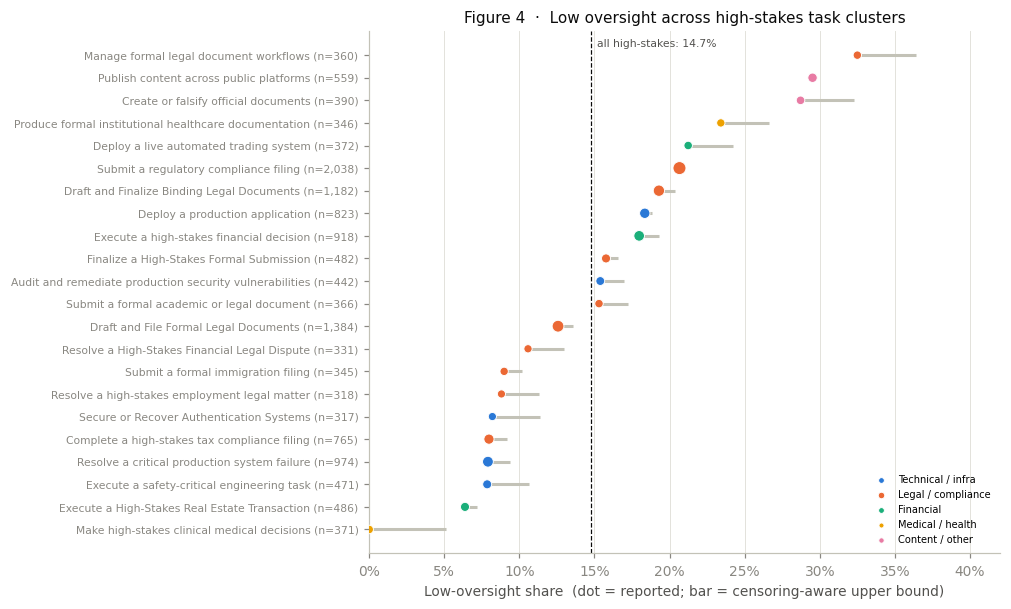

In [14]:
# ---- Figure 4: dot plot of low-oversight for high-stakes clusters (n>=300)
h = hs[hs.num_records >= 300].sort_values("low_lower")
dcol = {"technical":C[0],"legal_compliance":C[1],"financial":C[2],"medical":C[3],
        "content_other":C[4],"security_offense":MUTED}
dlab = {"technical":"Technical / infra","legal_compliance":"Legal / compliance","financial":"Financial",
        "medical":"Medical / health","content_other":"Content / other","security_offense":"Security-offense"}
fig, ax = plt.subplots(figsize=(7.4, 0.23*len(h)+1.1))
y = np.arange(len(h))
ax.hlines(y, h.low_lower, h.low_upper, color=AXIS, linewidth=2, zorder=1)
for d in dlab:
    dd = h[h.domain == d]
    if len(dd):
        ax.scatter(dd.low_lower, y[h.domain.values == d], s=np.sqrt(dd.num_records)*1.6,
                   color=dcol[d], zorder=3, label=dlab[d], edgecolors="white", linewidths=0.6)
ax.axvline(0.1474, color=INK, lw=0.8, ls="--")
ax.text(0.1474+0.004, len(h)-0.6, "all high-stakes: 14.7%", fontsize=7, color=INK2)
ax.set_yticks(y); ax.set_yticklabels([f"{n} (n={int(k):,})" for n,k in zip(h.name, h.num_records)], fontsize=7)
as_pct(ax, "x"); ax.set_xlim(0, 0.42); ax.grid(axis="y", visible=False)
ax.set_xlabel("Low-oversight share  (dot = reported; bar = censoring-aware upper bound)")
ax.legend(fontsize=6.5, loc="lower right", markerscale=0.6)
ax.set_title("Figure 4  ·  Low oversight across high-stakes task clusters", fontsize=10, color=INK)
plt.show()

---
## 4. Autonomy and outcome in Claude Code (+ Figures 2 and 3)

Autonomous sessions show higher AI-judged clear-success. Our **prior expectation** was that this is a composition artefact — easy *kinds* of task (extraction, classification) get delegated. We test that and, against our expectation, find it is **not** the explanation. We also flag a label-bias caution the paper adds.

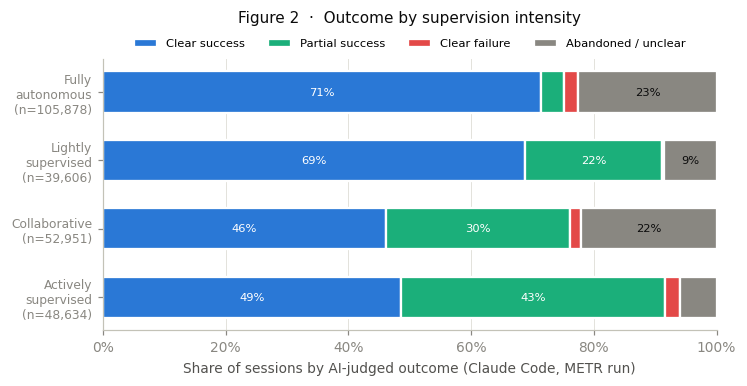

In [15]:
# ---- Figure 2: outcome by supervision level (stacked)
sorder = ["fully_autonomous","lightly_supervised","collaborative","actively_supervised"]
slab = {"fully_autonomous":"Fully\nautonomous","lightly_supervised":"Lightly\nsupervised",
        "collaborative":"Collaborative","actively_supervised":"Actively\nsupervised"}
outs = ["clear_success","partial_success","clear_failure","abandoned_or_unclear"]
olab = ["Clear success","Partial success","Clear failure","Abandoned / unclear"]
cols = [C[0], C[2], C[7], MUTED]
fig, ax = plt.subplots(figsize=(7.2, 3.2)); left = np.zeros(len(sorder))
for o,l,c in zip(outs, olab, cols):
    v = np.array([sup.loc[k, xcol("task_success", o)] for k in sorder])
    ax.barh(np.arange(len(sorder)), v, left=left, color=c, label=l, height=0.6, edgecolor="white", linewidth=1.5)
    for i,(vv,ll) in enumerate(zip(v,left)):
        if vv > 0.06: ax.text(ll+vv/2, i, f"{vv*100:.0f}%", ha="center", va="center",
                              fontsize=7.5, color="white" if c!=MUTED else INK)
    left += v
ax.set_yticks(np.arange(len(sorder)))
ax.set_yticklabels([f"{slab[k]}\n(n={int(sup.loc[k,'num_records']):,})" for k in sorder], fontsize=8)
ax.invert_yaxis(); as_pct(ax,"x"); ax.set_xlim(0,1); ax.grid(axis="y", visible=False)
ax.set_xlabel("Share of sessions by AI-judged outcome (Claude Code, METR run)")
ax.legend(loc="lower center", bbox_to_anchor=(0.5,1.0), ncol=4, fontsize=7.5)
ax.set_title("Figure 2  ·  Outcome by supervision intensity", fontsize=10, color=INK, pad=24)
plt.show()

In [16]:
# Cluster-level correlations over the 277 task_description clusters
td = facet(me, "task_description")
ACT = ["debugging_and_maintenance","infrastructure_and_devops","other","producing_written_artifacts",
       "research_and_learning","technical_review","writing_personal_code","writing_shared_code"]
td["fa"] = td[xcol("supervision_intensity","fully_autonomous")]
td["cs"] = td[xcol("task_success","clear_success")]
td["ab"] = td[xcol("task_success","abandoned_or_unclear")]
r_fa_cs, k = weighted_corr(td.fa.fillna(0), td.cs.fillna(0), td.num_records)
r_fa_ab, _ = weighted_corr(td.fa.fillna(0), td.ab.fillna(0), td.num_records)
print(f"weighted corr(fully_autonomous, clear_success)   = {r_fa_cs:+.2f}   (k={k})")
print(f"weighted corr(fully_autonomous, abandoned)       = {r_fa_ab:+.2f}")

# Decomposition: modal activity, then within-activity correlation + covariance split
acols = [xcol("work_activity_type", a) for a in ACT]
td["modal"] = td[acols].fillna(0).idxmax(axis=1).str.replace("work_activity_type:","").str.replace("_ratio","")
d = td.dropna(subset=["fa","cs"]).copy() if False else td.assign(fa=td.fa.fillna(0), cs=td.cs.fillna(0))
w = d.num_records.to_numpy()
mfa, mcs = np.average(d.fa,weights=w), np.average(d.cs,weights=w)
cov_total = np.average((d.fa-mfa)*(d.cs-mcs), weights=w)
gm = d.groupby("modal").apply(lambda x: pd.Series({"w":x.num_records.sum(),
        "fa":np.average(x.fa,weights=x.num_records), "cs":np.average(x.cs,weights=x.num_records)}))
cov_between = np.average((gm.fa-mfa)*(gm.cs-mcs), weights=gm.w)
def demean(col):
    m = d.groupby("modal").apply(lambda x: np.average(x[col],weights=x.num_records))
    return d[col] - d.modal.map(m)
r_within, _ = weighted_corr(demean("fa"), demean("cs"), w)
print(f"\nwithin-activity corr(fa, cs)                     = {r_within:+.2f}   (was {r_fa_cs:+.2f})")
print(f"between-activity share of covariance             = {cov_between/cov_total*100:.0f}%")

weighted corr(fully_autonomous, clear_success)   = +0.25   (k=277)
weighted corr(fully_autonomous, abandoned)       = +0.36

within-activity corr(fa, cs)                     = +0.34   (was +0.25)
between-activity share of covariance             = 12%


**The counter-to-expectation result.** If composition drove the correlation, controlling for activity would *shrink* it. Instead the within-activity correlation **rises** to +0.34 and only ~12% of the covariance is between activities. So the autonomy–success link operates *within* task type — most plausibly task difficulty or the user's prior confidence, neither observable here. It is **selection, not a safety property of autonomy**, and no causal claim is licensed. (The abandonment correlation, by contrast, *is* mostly compositional: +0.36 → +0.12 within activity.)

**Label-bias caution (added after review).** In a fully autonomous session the transcript has little user feedback for the judge to anchor on, so "clear success" is graded from the model's output alone — the setting where an AI judge grades most generously. Because that bias moves *with* the supervision variable, part of the success gap could be an artefact of the label. Figure 3 shows the cluster cloud.

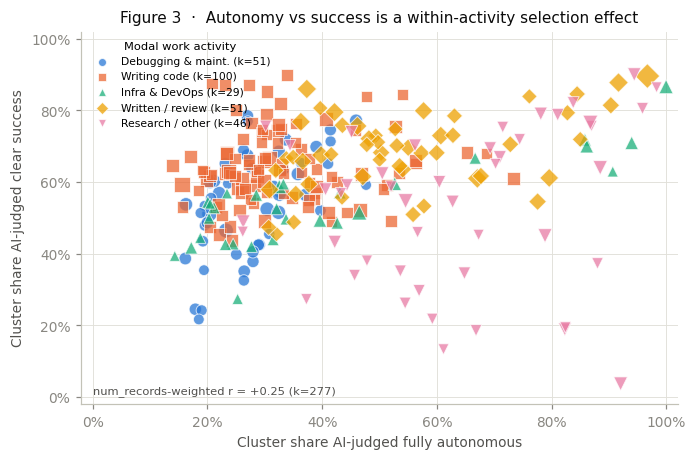

In [17]:
# ---- Figure 3: cluster autonomy vs clear-success, coloured by modal activity
grp = {"debugging_and_maintenance":"Debugging & maint.","writing_shared_code":"Writing code",
       "writing_personal_code":"Writing code","infrastructure_and_devops":"Infra & DevOps",
       "producing_written_artifacts":"Written / review","technical_review":"Written / review",
       "research_and_learning":"Research / other","other":"Research / other"}
td["grp"] = td.modal.map(grp)
gorder = ["Debugging & maint.","Writing code","Infra & DevOps","Written / review","Research / other"]
markers = ["o","s","^","D","v"]
fig, ax = plt.subplots(figsize=(7.0, 4.4))
for gname,c,m in zip(gorder, C, markers):
    dd = td[td.grp == gname]
    ax.scatter(dd.fa, dd.cs, s=np.sqrt(dd.num_records)*2.2, c=c, marker=m, alpha=0.75,
               edgecolors="white", linewidths=0.6, label=f"{gname} (k={len(dd)})")
ax.text(0.02, 0.03, f"num_records-weighted r = {r_fa_cs:+.2f} (k=277)", transform=ax.transAxes, fontsize=7.5, color=INK2)
ax.set_xlabel("Cluster share AI-judged fully autonomous"); ax.set_ylabel("Cluster share AI-judged clear success")
as_pct(ax,"x"); as_pct(ax); ax.set_xlim(-0.02,1.02); ax.set_ylim(-0.02,1.02)
ax.legend(fontsize=7, loc="upper left", markerscale=0.6, title="Modal work activity", title_fontsize=7.5)
ax.set_title("Figure 3  ·  Autonomy vs success is a within-activity selection effect", fontsize=10, color=INK)
plt.show()

---
## 5. The unwatched ending — the abandonment tail

Autonomous sessions carry a 22.5% abandoned-or-unclear rate. Where does that tail live? We find it concentrates in **session-mechanics / no-op** clusters (greetings, pings, empty inputs), which means "42.8% fully autonomous" should **not** be read as "42.8% of coding work delegated end to end".

In [18]:
# share of ALL abandoned sessions by supervision level
ab_n = {s: sup.loc[s, xcol("task_success","abandoned_or_unclear","num_records")] for s in SUP}
tot = sum(ab_n.values())
print("Share of ALL abandoned sessions coming from each level:")
for s in SUP: print(f"  {s:20s} {ab_n[s]/tot*100:4.1f}%")
print(f"  -> fully+lightly (low supervision): {(ab_n['fully_autonomous']+ab_n['lightly_supervised'])/tot*100:.1f}%")

# top task clusters by absolute abandoned sessions
td["ab_n"] = td[xcol("task_success","abandoned_or_unclear","num_records")]
top = td.sort_values("ab_n", ascending=False).head(8)[["cluster_name","num_records","fa","ab","cs"]].copy()
for c in ["fa","ab","cs"]: top[c] = (top[c]*100).round(1)
top.columns = ["cluster","n","autonomous_%","abandoned_%","clear_success_%"]
top.reset_index(drop=True)

Share of ALL abandoned sessions coming from each level:
  fully_autonomous     57.1%
  lightly_supervised    8.1%
  collaborative        28.0%
  actively_supervised   6.9%
  -> fully+lightly (low supervision): 65.1%


,cluster,n,autonomous_%,abandoned_%,clear_success_%
0,Initiate a conversation or greeting session,1352,92.0,95.8,3.7
1,Initialize or ping a coding assistant session,1028,82.3,78.2,18.9
2,Extract and structure knowledge from transcrip...,1446,78.8,48.9,45.0
3,"Install and troubleshoot dev tools, plugins, a...",1909,46.5,29.9,51.5
4,Explore and configure AI assistant capabilitie...,1197,42.2,42.0,43.3
5,"Search, list, and inspect files and directory ...",923,64.8,54.0,34.6
6,Clarify incomplete or ambiguous user requests,647,59.2,73.1,21.8
7,Debug and manage chat session history and pers...,798,56.9,58.5,29.7


**Reading it.** The single biggest contributor is *"Initiate a conversation or greeting session"* — 92% autonomous, 96% abandoned, 4% clear success. These are pings and empty prompts the labeller can't score, not delegated work. Two readings fit and the data can't separate them: (1) a chunk of "autonomous" volume is no-op invocations inflating both the autonomy share and the tail; (2) some of it is real unwatched work no one recorded. Either way, the paper recommends future releases separate no-op sessions.

---
## 6. Model version (descriptive only — no trend claim)

A single April–May snapshot cannot support a trend, because model choice, user population, and task mix are confounded. We report it descriptively only.

In [19]:
mv = facet(me, "model_version").set_index("cluster_name")
mrows = []
for name, row in mv.iterrows():
    if row.num_records >= 10000:
        mrows.append({"model_version": name, "n": int(row.num_records),
                      "fully_autonomous_%": round(row[xcol("supervision_intensity","fully_autonomous")]*100,1)})
pd.DataFrame(mrows).sort_values("fully_autonomous_%")

,model_version,n,fully_autonomous_%
3,claude-4-7-opus,49862,30.9
1,claude-4-6-opus,57038,38.5
2,claude-4-6-sonnet,85753,40.3
0,claude-4-5-haiku,42883,65.7


The fully-autonomous share ranges from ~31% (Opus 4.7) to ~66% (Haiku 4.5). The small, inexpensive model is the natural choice for scripted/sub-agent use, which is the obvious confound — so we draw no conclusion about models becoming "more autonomous".

---
## 7. Summary

| Finding | Number | Strength |
|---|---|---|
| Low oversight, high-stakes | **14.7%** (one in 6.8), n=19,447 | Exact count, uncensored — **strong** |
| Oversight–stakes gradient | 28.6% → 21.3% → 14.7% | All pairwise diffs CI-clean — **strong** |
| Engineer asymmetry (tech < legal/financial) | −6.2 pp lower bound | CI excludes 0 at lower bound only — **suggestive** |
| Autonomy–success is within-activity selection | r +0.25 → +0.34 within activity | Robust to composition — **strong (as non-causal)** |
| Abandonment tail is session-mechanics | 57% of abandoned = autonomous; top cluster 96% | Descriptive — **strong** |

**The through-line:** every number is AI-judged, the censored cells are bounded rather than zeroed, and conversation-level (uncensored) tables are preferred over cluster-level inference wherever both exist. That discipline is what lets the title rest on the one number — 14.7% — that has no censoring in it at all.

*Data © Anthropic, CC-BY-4.0 (Handa et al., 2026). This notebook reproduces the paper end to end; see the paper's Limitations section for the full list of caveats, foremost that all labels are unvalidated model judgements.*